In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# P1 — Load, Clean & Merge

In [2]:
df=pd.read_csv("C:/Users/MAYUR MAKVANA/OneDrive/Desktop/exam2/data/raw/tickets.csv")

display(df.head())
print("\nDataset info:")
print(df.info())
print("\nshape:",df.shape)

,ticket_id,month,team_id,channel,resolution_hours,satisfaction
0,1,Jan,T1,Email,12,4
1,2,Jan,T2,Chat,28,3
2,3,Jan,T3,Phone,36,2
3,4,Jan,T4,Email,20,4
4,5,Feb,T1,Chat,8,5



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         13 non-null     int64 
 1   month             13 non-null     object
 2   team_id           13 non-null     object
 3   channel           13 non-null     object
 4   resolution_hours  13 non-null     int64 
 5   satisfaction      13 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 756.0+ bytes
None

shape: (13, 6)


In [3]:
lookup = pd.read_csv("C:/Users/MAYUR MAKVANA/OneDrive/Desktop/exam2/data/raw/teams.csv")

display(lookup.head())
print("\nDataset info:")
print(lookup.info())
print("\nshape:",lookup.shape)

,team_id,team,department
0,T1,AccountCare,Service
1,T2,BillingHelp,Service
2,T3,AppSupport,Technical
3,T4,DeviceHelp,Technical



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   team_id     4 non-null      object
 1   team        4 non-null      object
 2   department  4 non-null      object
dtypes: object(3)
memory usage: 228.0+ bytes
None

shape: (4, 3)


# clean

In [4]:
print("resolution_hours data type:",df["resolution_hours"].dtypes)
print("satisfaction data type:",df["satisfaction"].dtypes)

resolution_hours data type: int64
satisfaction data type: int64


In [5]:
print("Duplicates:",df.duplicated().sum())

Duplicates: 1


In [6]:
# remove duplicate
df=df.drop_duplicates().copy()

In [7]:
print("Duplicates:",df.duplicated().sum())

Duplicates: 0


# Merge

In [8]:
M_df = df.merge(lookup,on="team_id",how="left",validate="many_to_one")

display(M_df.head())
print("\nDataset info:")
print(M_df.info())
print("\nshape:",M_df.shape)

,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department
0,1,Jan,T1,Email,12,4,AccountCare,Service
1,2,Jan,T2,Chat,28,3,BillingHelp,Service
2,3,Jan,T3,Phone,36,2,AppSupport,Technical
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical
4,5,Feb,T1,Chat,8,5,AccountCare,Service



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         12 non-null     int64 
 1   month             12 non-null     object
 2   team_id           12 non-null     object
 3   channel           12 non-null     object
 4   resolution_hours  12 non-null     int64 
 5   satisfaction      12 non-null     int64 
 6   team              12 non-null     object
 7   department        12 non-null     object
dtypes: int64(3), object(5)
memory usage: 900.0+ bytes
None

shape: (12, 8)


In [9]:
# Assert Dataset

assert len(M_df) == 12
assert M_df["team"].isna().sum()==0

# Derived Field & Department Analysis

In [10]:
# create breach_flag  column
M_df["breach_flag"] = (M_df["resolution_hours"]>24).astype(int)

display(M_df[["resolution_hours","breach_flag"]].head())

,resolution_hours,breach_flag
0,12,0
1,28,1
2,36,1
3,20,0
4,8,0


In [11]:
summary = M_df.groupby("department",as_index=False).agg(
    total_tickets=("ticket_id","count"),
    total_breach=("breach_flag","sum")
)

summary["SLA_breach_rate"]=summary["total_breach"] / summary["total_tickets"] * 100

display(summary)

,department,total_tickets,total_breach,SLA_breach_rate
0,Service,6,2,33.333333
1,Technical,6,3,50.000000


In [17]:
team = M_df.groupby("team",as_index=False).agg(
    total_tickets=("ticket_id","count"),
    breach_flag=("breach_flag","sum")
)

team["breach_rate"]=team["breach_flag"] / team["total_tickets"] * 100

highest_team = team.loc[team["breach_rate"].idxmax()]

team

,team,total_tickets,breach_flag,breach_rate
0,AccountCare,3,0,0.000000
1,AppSupport,3,2,66.666667
2,BillingHelp,3,2,66.666667
3,DeviceHelp,3,1,33.333333


In [13]:
print("Top Team name:",highest_team["team"])
print("Total tickets:",highest_team["total_tickets"])
print("Total breach: ",highest_team["breach_flag"])
print("breach rate:",highest_team["breach_rate"])

Top Team name: AppSupport
Total tickets: 3
Total breach:  2
breach rate: 66.66666666666666


#  Chart & Exports

In [14]:
monthly_summ = M_df.groupby("month")["resolution_hours"].mean().reindex(["Jan","Feb","Mar"])

monthly_summ

month
Jan    24.0
Feb    24.0
Mar    23.5
Name: resolution_hours, dtype: float64

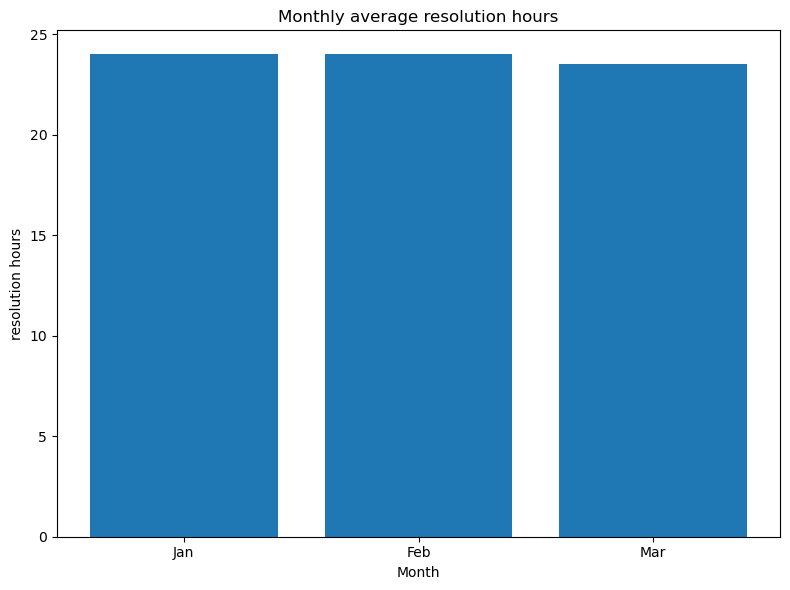

In [15]:
plt.figure(figsize=(8,6))
plt.bar(monthly_summ.index,monthly_summ.values)
plt.title("Monthly average resolution hours")
plt.xlabel("Month")
plt.ylabel("resolution hours")
plt.tight_layout()
plt.savefig("C:/Users/MAYUR MAKVANA/OneDrive/Desktop/exam2/output/python_chart.png")
plt.show()

# Exports 

In [16]:
summary.to_csv("C:/Users/MAYUR MAKVANA/OneDrive/Desktop/exam2/output/python_summary.csv",index=False)
M_df.to_csv("C:/Users/MAYUR MAKVANA/OneDrive/Desktop/exam2/output/clean_data.csv",index=False)